# 01a · The gentlest models: linear & logistic regression

*Before trees and neural nets: the two models every course starts with.*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** a load–depth curve + the Al–Cu map

### 🎯 What you'll learn
1. **linear regression**: fit a straight line to predict one number from another — on data where a line really is the right model (**Kick's law**),
2. how to read a **slope**, **intercept** and **R²**,
3. **logistic regression**: the same idea bent into a **classifier** (predict a phase),
4. what a **decision boundary** is and how a model turns features into a probability.

### 🧭 What you need to know first
- Notebook **01** (features, standardisation).
- R² is introduced here and revisited in notebook 12.

> 🧭 **Where this fits.** These are the simplest supervised models, a great first rung. Linear
> regression predicts a **number**; logistic regression predicts a **class**. Everything later
> (trees, forests, CNNs) is a more flexible answer to these same two questions.

### Step 0: set-up

Before you start, run the cell below: select it and press **Shift + Enter**.

> 🟢 **On Colab** it clones the repo and installs the few packages Colab lacks, so give it about a minute. After a local `pip install -r requirements.txt` there is nothing to wait for.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, accuracy_score
rng = np.random.default_rng(0)

## 1 · Linear regression: a real straight line (Kick's law)

When is a straight line the *right* model? When the physics says so. A nanoindentation **loading
curve** obeys **Kick's law**, `P = C·h²`: the load grows with the **square** of the depth. So if we
plot load against **depth-squared** (`h²`, not `h`), the points fall on a straight line and linear
regression fits it almost perfectly. The slope `C` is a material constant (it scales with hardness).

> 🧠 **linear regression**: fit a straight line (or flat plane) that minimises the squared distance to the data. The output is a number.

> 🧠 **slope & intercept**: the line's tilt and where it crosses the axis: `P ≈ slope · h² + intercept`. Kick's law makes the slope the constant `C`, with the line passing close to the origin.

> ✅ **What appears:** the fitted slope `C` and an **R²** very close to 1, plus two panels — the raw curve (`P` vs `h`, curved) and the same data as `P` vs `h²` (a straight line with the red best-fit through it).

Kick's constant C = 119.0 mN/um^2   (the line's slope)
R^2 = 0.9992   (1 = a perfect straight line)


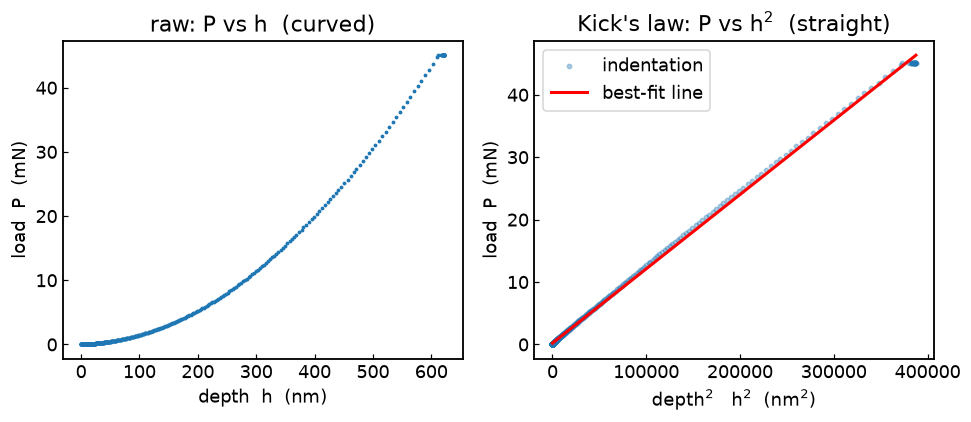

In [3]:
# One nanoindentation LOADING curve: depth h (nm) and load P (mN).
h_nm, P_mN = mm.load_curves(1)[0]                  # load_curves(n) -> list of (depth, load)
h_nm = np.asarray(h_nm); P_mN = np.asarray(P_mN)

# Kick's law describes the loading half, so keep the points up to peak load.
top = int(np.argmax(P_mN))
h = h_nm[:top + 1]                                 # depth on the way in (nm)
P = P_mN[:top + 1]                                 # load on the way in (mN)
h2 = (h ** 2).reshape(-1, 1)                        # the predictor is depth SQUARED (2-D for sklearn)

lin = LinearRegression().fit(h2, P)               # fit  P = C·h²  -> a straight line in h²
P_pred = lin.predict(h2)
print(f"Kick's constant C = {lin.coef_[0] * 1e6:.1f} mN/um^2   (the line's slope)")
print(f"R^2 = {r2_score(P, P_pred):.4f}   (1 = a perfect straight line)")

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].plot(h, P, ".", ms=3)                        # raw data curves upward
ax[0].set_xlabel("depth  h  (nm)"); ax[0].set_ylabel("load  P  (mN)")
ax[0].set_title("raw: P vs h  (curved)")
ax[1].scatter(h ** 2, P, s=8, alpha=.35, label="indentation")   # in h^2 it is a straight line
order = np.argsort(h ** 2)
ax[1].plot((h ** 2)[order], P_pred[order], "r-", lw=2, label="best-fit line")
ax[1].set_xlabel("depth$^2$   h$^2$  (nm$^2$)"); ax[1].set_ylabel("load  P  (mN)")
ax[1].set_title("Kick's law: P vs h$^2$  (straight)"); ax[1].legend()
fig.tight_layout()

*🖼 **Figure.** Left: the raw loading curve bends upward, because `P` grows like `h²`. Right: plotting against `h²` straightens it into a line and least-squares nails it (R² ≈ 0.999). That is what linear regression looks like when the relationship really is linear — unlike forcing one line across a two-phase cloud.*

## 2 · Logistic regression: predict the phase

Now a **classification** task: which phase is an indent? We first make two-phase labels by clustering
`H, E` (as in notebook 02), then let **logistic regression** find the straight line that best
separates them. Despite the name, it is a **classifier**.

> 🧠 **logistic regression**, a linear classifier: it combines the features into a score, then squashes the score to a probability between 0 and 1 with an S-shaped (sigmoid) curve. Above 0.5 → one class, below → the other.

> 🧠 **decision boundary**: the line (or surface) where the model switches its prediction from one class to the other. For logistic regression it is straight.

> ✅ **What appears:** a printed accuracy (~0.9+) and a scatter of the two phases with the straight **decision boundary** drawn through them.

training accuracy: 0.998


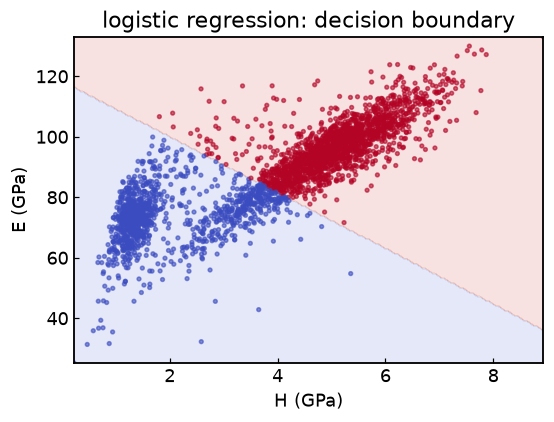

In [4]:
df = mm.load_map("alcu_2um")                       # the Al–Cu two-phase map
samp = df.sample(3000, random_state=0)             # a subsample for a clean plot
X = samp[["H", "E"]].values
# Labels from clustering (unsupervised), named so 1 = harder phase.
lab = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(X))
y = (lab == df.loc[samp.index].groupby(lab)["H"].median().idxmax()).astype(int)

# Standardise, then fit logistic regression.
sc = StandardScaler().fit(X); Xs = sc.transform(X)
clf = LogisticRegression().fit(Xs, y)
print("training accuracy:", round(accuracy_score(y, clf.predict(Xs)), 3))

# Draw the decision boundary on a grid over H–E space.
hh, ee = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 200),
                     np.linspace(X[:, 1].min(), X[:, 1].max(), 200))
grid = sc.transform(np.c_[hh.ravel(), ee.ravel()])
zz = clf.predict(grid).reshape(hh.shape)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.contourf(hh, ee, zz, alpha=.15, cmap="coolwarm")           # coloured regions
ax.scatter(X[:, 0], X[:, 1], c=y, s=6, cmap="coolwarm", alpha=.6)
ax.set_xlabel("H (GPa)"); ax.set_ylabel("E (GPa)"); ax.set_title("logistic regression: decision boundary")
fig.tight_layout()

*🖼 **Figure.** The shaded regions are the model's two 'territories'; the line between them is the decision boundary. Logistic regression can only draw a straight one, enough here because the phases separate neatly.*

## 3 · It also gives probabilities

Logistic regression doesn't just say 'phase 1'. It reports **how confident** it is (like the GMM in
notebook 02). Points near the boundary get probabilities near 0.5.

> ✅ **What appears:** a scatter coloured by the predicted probability of the hard phase: a smooth gradient from 0 to 1 across the boundary.

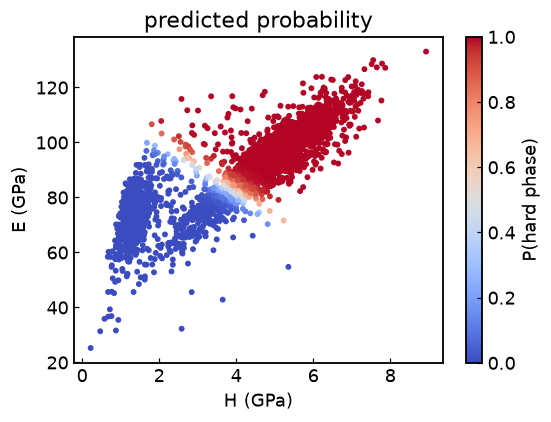

In [5]:
proba = clf.predict_proba(Xs)[:, 1]               # probability of the hard phase
fig, ax = plt.subplots(figsize=(5.2, 4))
s = ax.scatter(X[:, 0], X[:, 1], c=proba, s=8, cmap="coolwarm")
plt.colorbar(s, label="P(hard phase)")
ax.set_xlabel("H (GPa)"); ax.set_ylabel("E (GPa)"); ax.set_title("predicted probability")
fig.tight_layout()

*🖼 **Figure.** The colour is the model's confidence. The fuzzy band at ~0.5 marks indents the model considers borderline, exactly the phase boundary.*

### ✅ Self-check
A quick check that the results above sit in a reasonable range. If an edit pushes them off, the next cell fails loudly with an `AssertionError` so you notice straight away.

In [6]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert r2_score(P, P_pred) > 0.98, "Kick's law: load is linear in depth^2, so R^2 should be very high"
assert accuracy_score(y, clf.predict(Xs)) > 0.9, "logistic regression should separate the phases"
print("self-check passed ✓ — line fit and classifier work")

self-check passed ✓ — line fit and classifier work


## ✅ Recap
- **Linear regression** fits a line to predict a number, and shines when the relationship really is linear — Kick's law (`load ∝ depth²`) is a textbook case. Judge the fit with **R²**.
- **Logistic regression** is a linear **classifier**: it draws a straight **decision boundary** and reports a **probability**.
- These are the baselines to beat. Reach for trees/forests (notebook 03) when a straight line isn't enough.

## 🔧 Try it yourself
Small edits, real insight. Try these one at a time:
1. Fit `P` against **`h`** instead of `h²`. Is the R² as high? The wrong variable makes the line miss the curve — that is the whole point.
2. Give logistic regression only `H` (drop `E`). Does the boundary become a vertical line? Does accuracy drop?
3. Add `HE` as a third feature to the classifier. Does training accuracy improve?

## 🩹 Common errors & fixes
- **`ValueError: Expected 2D array`** → sklearn wants the predictor 2-D: reshape a single feature with `(h**2).reshape(-1, 1)`, or use double brackets `df[["H"]]`.
- **Boundary looks flipped** → cluster ids are arbitrary; we name the hard phase by median H, so the colours stay consistent.
- **Accuracy is suspiciously perfect** → remember the labels came from clustering the same features; notebook 03a shows how to evaluate honestly.

---
**Next:** **`02a_knn_classifier.ipynb`**: classify by nearest neighbours, a model with no straight-line assumption at all.